## Elastic scattering on a local optical potential

This will demonstrate how jitr is designed for parameteric optical potentials to interface with solvers.

In [1]:
from jitr.reactions.reaction import Reaction


In [2]:
neutron = (1, 0)
proton = (1, 1)

In [3]:
target = (208, 82)
projectile = proton
energy_lab = 80
reaction = Reaction(target=target, projectile=projectile, process="El")
kinematics = reaction.kinematics(energy_lab)
kinematics

ChannelKinematics(Elab=80, Ecm=79.6143271413054, mu=np.float64(1012.3503270110435), k=np.float64(1.9944672808011834), eta=np.float64(1.5392055587613254))

# We will use the pre-defined class `LocalOpticalPotential`

Although, in general, one can define whatever interaction they want. This is just a handy tool.

In [4]:
from jitr.optical_potentials import LocalOpticalPotential
help(LocalOpticalPotential)

Help on class LocalOpticalPotential in module jitr.optical_potentials.omp:

class LocalOpticalPotential(SingleChannelOpticalModel)
 |  LocalOpticalPotential(scale_radii_by_At_and_Ap=False)
 |
 |  A simple local optical potential which can describe elastic
 |  nucleon-nucleus or nucleus-nucleus scattering using a central and
 |  spin-orbit interaction, without any explicit energy or mass
 |  dependence in the potential parameters aside from scaling reduced
 |  radii by A^(1/3) of the target or by (A_target^(1/3) +
 |  A_projectile^(1/3)).
 |
 |  Method resolution order:
 |      LocalOpticalPotential
 |      SingleChannelOpticalModel
 |      builtins.object
 |
 |  Methods defined here:
 |
 |  __init__(self, scale_radii_by_At_and_Ap=False)
 |      Parameters:
 |      ----------
 |      scale_radii_by_At_and_Ap : bool
 |          Whether to scale the radius parameters by A_target^(1/3) of
 |          the target or by (A_target^(1/3) + A_projectile^(1/3)).
 |
 |          Default is False, w

In [5]:
omp = LocalOpticalPotential()
omp.params

['Vv',
 'rv',
 'av',
 'Wv',
 'rw',
 'aw',
 'Wd',
 'Vd',
 'rd',
 'ad',
 'Vso',
 'Wso',
 'rso',
 'aso',
 'rc']

## Randomly generate a bunch of parameters
In reality, we would like to fit these to data

In [6]:
import numpy as np
means = np.array([56, 1.2, 0.7, 5, 1.2, 0.7, 13, 6, 1.3, 0.9, 8, 4, 1.1, 0.7, 1.2])
cov = np.diag( (means*0.01)**2 )
samples = np.random.multivariate_normal(means, cov, 1000)

In [7]:
from pandas import DataFrame
df = DataFrame(samples, columns=omp.params)
df.head()

,Vv,rv,av,Wv,rw,aw,Wd,Vd,rd,ad,Vso,Wso,rso,aso,rc
0,55.015088,1.209414,0.696804,4.963839,1.201030,0.692784,13.020579,5.945471,1.277847,0.898288,8.008047,3.973895,1.088095,0.701805,1.186600
1,56.531944,1.170771,0.695596,5.025508,1.200523,0.703377,13.050436,5.861296,1.298952,0.889916,7.986076,3.986041,1.093631,0.699342,1.188827
2,56.160159,1.219166,0.704586,5.101399,1.191920,0.688513,13.308796,5.992016,1.284486,0.913175,7.923045,4.001935,1.088144,0.700139,1.176008
3,55.948141,1.188358,0.713953,4.960804,1.203919,0.701563,12.999151,5.905455,1.298232,0.900483,8.021114,4.044711,1.091434,0.691917,1.199783
4,55.763570,1.202381,0.700431,4.994876,1.186830,0.684913,12.865722,5.993363,1.304371,0.898507,7.955069,4.068356,1.084350,0.703892,1.197832


## How do we calculate observables? 
We will use `jitr.xs.elastic.DifferentialWorkspace`. We will see how this is set up to interface with `omp` and other classes that have the same structure

In [8]:
from jitr.xs import elastic
help(elastic.DifferentialWorkspace.xs)

Help on function xs in module jitr.xs.elastic:

xs(
    self,
    interaction_central,
    interaction_spin_orbit,
    interaction_coulomb=None,
    args_central=None,
    args_spin_orbit=None,
    args_coulomb=None
)
    Returns a dataclass with the following attributes:
    -   differential cross section [mb/Sr]
    -   analyzing power [dimensionless]
    -   total cross section [mb]
    -   reaction cross secton [mb]



Exactly the information that the solver workspace needs is what is provided by the `omp` class:

In [9]:
help(omp.interaction_central)

Help on function central in module jitr.optical_potentials.omp:

central(
    r: float,
    Vv: float,
    Rv: float,
    av: float,
    Wv: float,
    Rw: float,
    aw: float,
    Wd: float,
    Vd: float,
    Rd: float,
    ad: float
)
    Standard Woods-Saxon based central potential. Note that, by
    convention, the capital R parameters are radii in fm, and are not
    multiplied by A^(1/3). The diffuseness parameters are in fm, and the
    strengths are in MeV.

    Parameters:
    ----------
    r : float
        The radius at which to evaluate the potential.
    Vv : float
        The real volume strength of the potential.
    Rv : float
        The radius parameter for the real volume term.
    av : float
        The diffuseness parameter for the real volume term.
    Wv : float
        The imaginary volume strength of the potential.
    Rw : float
        The radius parameter for the imaginary volume term.
    aw : float
        The diffuseness parameter for the imaginary vol

In [10]:
help(omp.interaction_spin_orbit)

Help on function spin_orbit in module jitr.optical_potentials.omp:

spin_orbit(r: float, Vso: float, Wso: float, Rso: float, aso: float) -> complex
    Standard Thomas form for the spin-orbit potential. Note that, by
    convention, the capital R parameters are radii in fm, and are not
    multiplied by A^(1/3). The diffuseness parameters are in fm, and the
    strengths are in MeV.

    Parameters:
    ----------
    r : float
        The radius at which to evaluate the potential.
    Vso : float
        The real strength of the spin-orbit potential.
    Wso : float
        The imaginary strength of the spin-orbit potential.
    Rso : float
        The radius parameter for the spin-orbit potential.
    aso : float
        The diffuseness parameter for the spin-orbit potential.



In [11]:
help(omp.interaction_coulomb)

Help on function coulomb_charged_sphere in module jitr.optical_potentials.potential_forms:

coulomb_charged_sphere(r, zz, r_c)



In [12]:
help(omp.params_by_term)

Help on method params_by_term in module jitr.optical_potentials.omp:

params_by_term(
    reaction: reaction.Reaction,
    kinematics: kinematics.ChannelKinematics,
    Vv: float,
    rv: float,
    av: float,
    Wv: float,
    rw: float,
    aw: float,
    Wd: float,
    Vd: float,
    rd: float,
    ad: float,
    Vso: float,
    Wso: float,
    rso: float,
    aso: float,
    rc: float
) -> tuple method of jitr.optical_potentials.omp.LocalOpticalPotential instance
    A simple implementation of the central_and_spin_orbit_params
    method for a local optical potential. The only dependence on
    the reacting system is through the A^(1/3) scaling of the radius
    parameters and the Z*Zp dependence of the Coulomb potential. The
    strengths and diffuseness parameters are fixed and do not depend
    on the reaction or kinematics.

    Parameters:
    ----------
    reaction : jitr.reactions.reactions.Reaction
        The reaction for which the parameters are being calculated.
    ki

## Do you see the vision?
Let's set up a solver and see this thing in action.

In [13]:
from jitr.rmatrix import Solver as SolverKernel

In [14]:
solver = elastic.DifferentialWorkspace.build_from_system(
    reaction=reaction,
    kinematics=kinematics,
    channel_radius_fm=30,
    solver=SolverKernel(50),
    lmax=80,
    angles=np.linspace(0.1,np.pi,180),
)

Now running calculations is simple!
Once it's been compiled, it's fast:

In [15]:
from tqdm import tqdm

In [16]:
%%time
num_samples, num_params = df.shape
xs_ratio = np.zeros((num_samples, solver.angles.size))
Ay = np.zeros((num_samples, solver.angles.size))

for i in tqdm(range(num_samples)):
    central_params, spin_orbit_params, coulomb_params = omp.params_by_term(
        reaction,
        kinematics,
        *samples[i,:],
    )
    xs = solver.xs(
        interaction_central=omp.interaction_central,
        interaction_spin_orbit=omp.interaction_spin_orbit,
        interaction_coulomb=omp.interaction_coulomb,
        args_central=central_params,
        args_spin_orbit=spin_orbit_params,
        args_coulomb=coulomb_params,
    )
    xs_ratio[i,:] = xs.dsdo / solver.rutherford
    Ay[i,:] = xs.Ay

100%|██████████| 1000/1000 [00:26<00:00, 37.62it/s]

CPU times: user 26 s, sys: 584 ms, total: 26.6 s
Wall time: 26.6 s


In [17]:
from matplotlib import pyplot as plt

Text(0, 0.5, '$\\frac{d \\sigma}{d\\Omega} / \\frac{d \\sigma_{\\text{R}}}{d\\Omega}$ [dimensionless]')

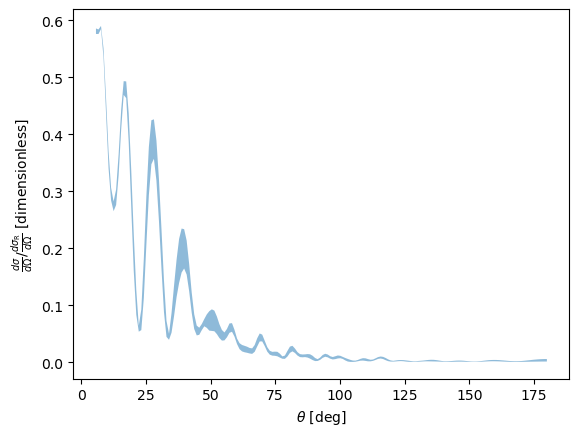

In [18]:
l,h = np.percentile(xs_ratio, [5,95], axis=0)
plt.fill_between(np.rad2deg(solver.angles), l,h, alpha=0.5)
plt.xlabel(r"$\theta$ [deg]")
plt.ylabel(r"$\frac{d \sigma}{d\Omega} / \frac{d \sigma_{\text{R}}}{d\Omega}$ [dimensionless]")

Text(0, 0.5, '$A_y$ [dimensionless]')

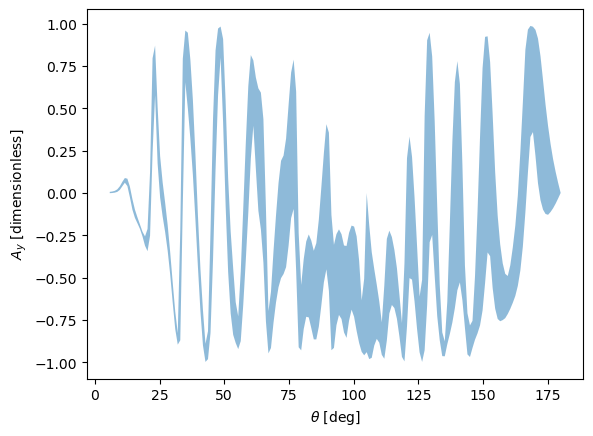

In [19]:
l,h = np.percentile(Ay, [5,95], axis=0)
plt.fill_between(np.rad2deg(solver.angles), l,h, alpha=0.5)
plt.xlabel(r"$\theta$ [deg]")
plt.ylabel(r"$A_y$ [dimensionless]")